# Assingment 3: GNN

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### 2.1 Data Import, Visualization and Exploratory Analysis (5 points)

- Load both the node features (`large twitch features.csv`) and edge list (`large twitch edges.csv`)

- Construct the graph using PyTorch Geometric

- Perform exploratory data analysis:

  - Analyze the distribution of node features
  - Compute basic graph statistics (number of nodes, edges, average degree, etc.)
  - Visualize degree distribution
  - Create visualizations showing the distribution of your target variables
  - Analyze feature correlations


In [3]:
twitch_edges = pd.read_csv("data/twitch_gamers/large_twitch_edges.csv")

twitch_nodes = pd.read_csv("data/twitch_gamers/large_twitch_features.csv")

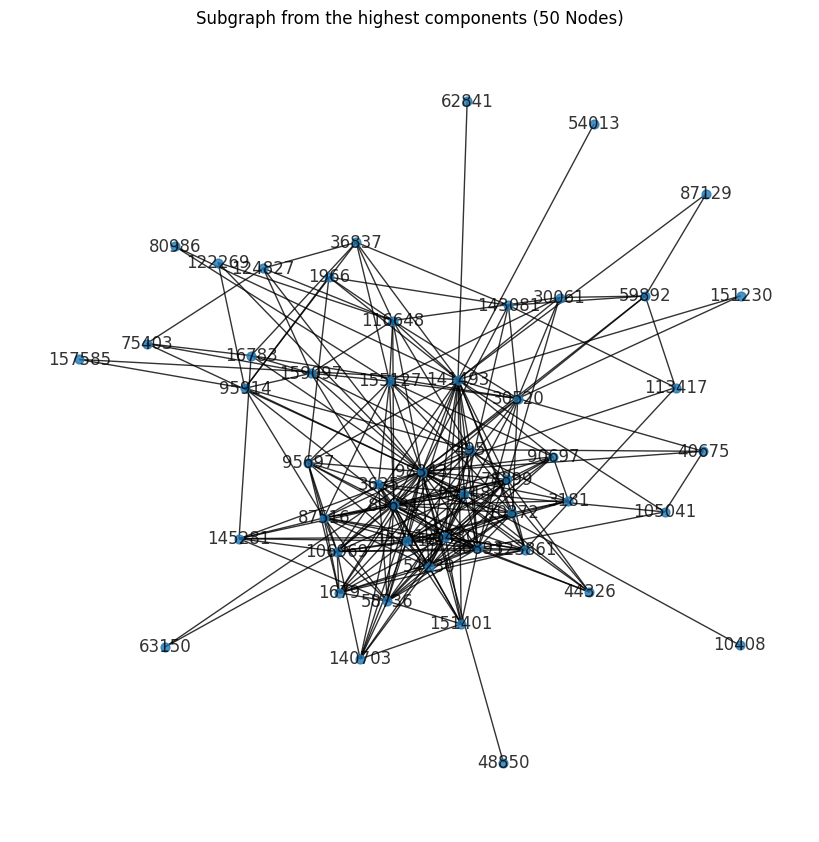

In [4]:
import torch
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt
import networkx as nx

edge_index = torch.tensor(twitch_edges.values.T, dtype=torch.long)

numerical_features = twitch_nodes.select_dtypes(include=['int64', 'float64'])

x = torch.tensor(numerical_features.values, dtype=torch.float)
data = Data(x=x, edge_index=edge_index)

edge_list = data.edge_index.numpy().T
G = nx.Graph()
G.add_edges_from(edge_list)

largest_cc = max(nx.connected_components(G), key=len)
G_largest = G.subgraph(largest_cc)
nodes_sample = list(G_largest.nodes)[:50] 
G_sample = G_largest.subgraph(nodes_sample)

plt.figure(figsize=(8, 8))
nx.draw(G_sample, node_size=40, alpha=0.8, with_labels=True)
plt.title(f"Subgraph from the highest components ({50} Nodes)")
plt.show()


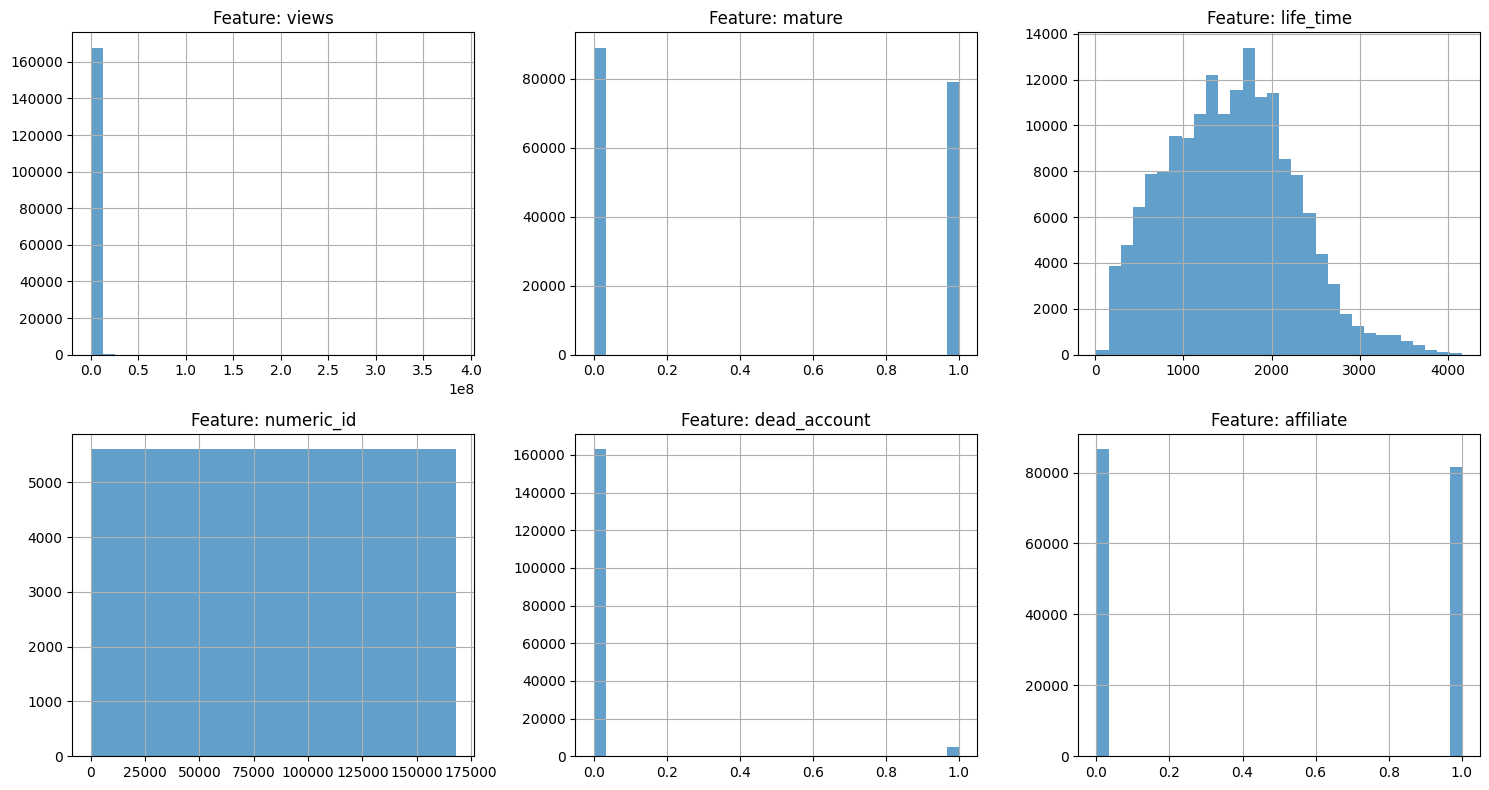

In [5]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_features.columns, 1):
    plt.subplot(2, 3, i)
    numerical_features[col].hist(bins=30, alpha=0.7)
    plt.title(f"Feature: {col}")
plt.tight_layout()
plt.show()

In [6]:
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Average degree: {(2 * data.num_edges) / data.num_nodes}")
print(f'Number of node features: {data.num_node_features}')

Number of nodes: 168114
Number of edges: 6797557
Average degree: 80.86842261798542
Number of node features: 6


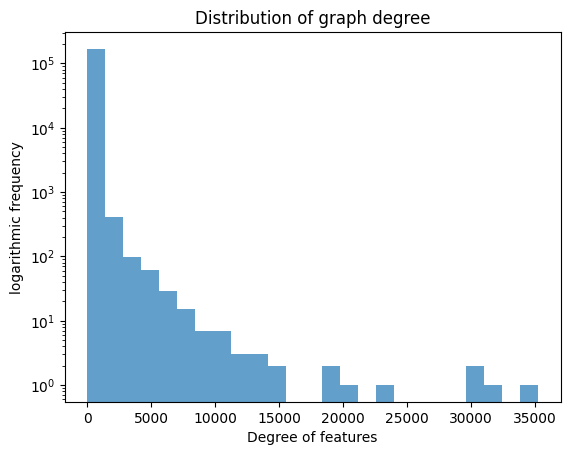

In [7]:
degrees = [deg for node, deg in G.degree()]

plt.hist(degrees, bins=25, alpha=0.7,log=True)
plt.title("Distribution of graph degree")
plt.ylabel("logarithmic frequency")
plt.xlabel("Degree of features")
plt.show()

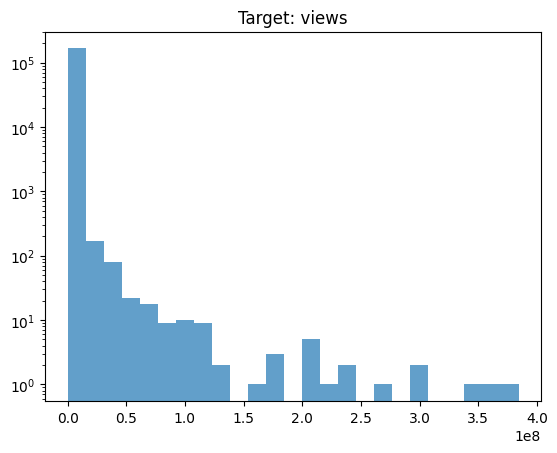

In [8]:
plt.hist(twitch_nodes["views"], bins=25, alpha=0.7,log=True)
plt.title("Target: views")
plt.show()

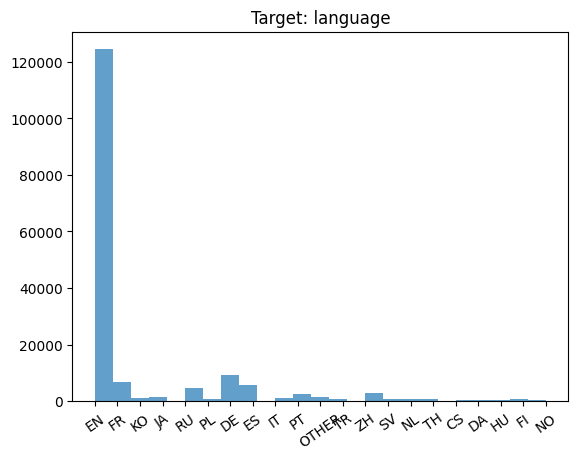

In [9]:
plt.hist(twitch_nodes["language"], bins=25, alpha=0.7)
plt.title("Target: language")
plt.xticks(rotation=35)
plt.show()

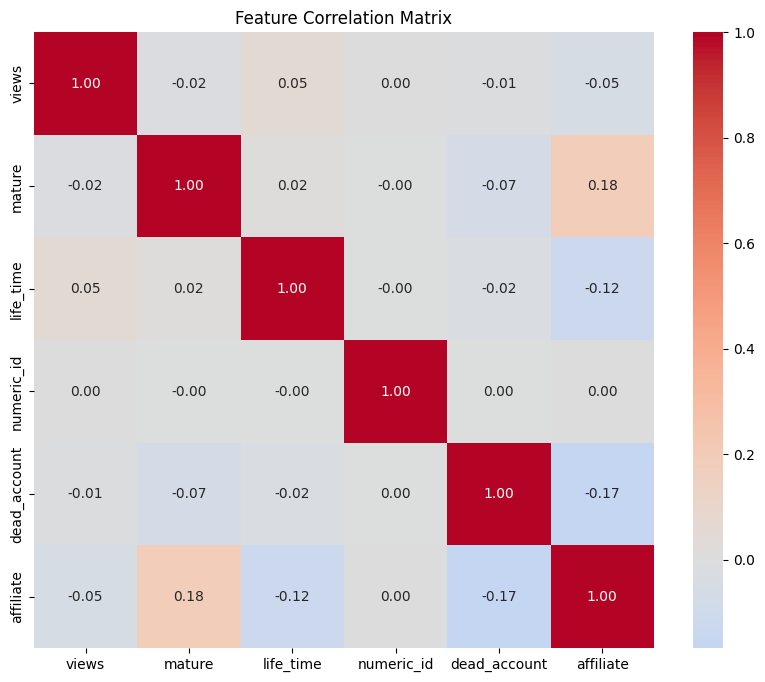

In [10]:
corr_matrix = numerical_features.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

### 2.2 GNN Model Training and Comparison (10 points)
- Train and evaluate GNN models for two classification tasks:

- For each task:
  - Implement a Convolutional GNN architecture
  - Train an MLP baseline using the same features (without graph structure)
  - Use appropriate train/validation/test splits (e.g. 60%/20%/20%)
  - Handle class imbalance (if relevant)
  - Report comprehensive metrics
  - Include confusion matrices and classification reports

#### 2.2.1 Task A: High Views Prediction
- Target: Binary classification (≤10k vs >10k total views)
- Hypothesis: Popular streamers network with other popular streamers (success homophily)
- Important: Exclude the views feature from input to prevent data leakage
- Features: mature, life time, dead account, affiliate, language, temporal features

In [11]:
from sklearn.preprocessing import LabelEncoder

twitch_nodes['language_enc'] = LabelEncoder().fit_transform(twitch_nodes['language'])

features = ['mature', 'life_time', 'dead_account', 'affiliate', 'language_enc']


x = torch.tensor(twitch_nodes[features].values, dtype=torch.float)
y = torch.tensor((twitch_nodes["views"] > 10000).astype(int).values, dtype=torch.long)
gnn_views = Data(x=x, edge_index=edge_index, y=y)

In [12]:
# Import necessary PyTorch functions and PyTorch Geometric modules
import torch.nn.functional as F  # Contains activation functions, dropout, softmax, etc.
from torch_geometric.nn import GCNConv  # Graph Convolutional Network layer implementation

# Define the Graph Neural Network (GNN) model
# 2 layers of graph convulution, these layers work like mlp layers
class GNN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        """
        Initialize a 2-layer Graph Convolutional Network.

        Args:
            input_dim: Number of input features per node
            hidden_dim: Size of hidden layer (number of features after first convolution)
            output_dim: Number of output classes (final prediction dimension)
        """
        super(GNN, self).__init__()  # Initialize the parent class (torch.nn.Module)

        # First graph convolutional layer
        # Transforms node features from input_dim to hidden_dim dimensions
        self.conv1 = GCNConv(input_dim, hidden_dim)

        # Second graph convolutional layer
        # Transforms node features from hidden_dim to output_dim dimensions
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, data):
        """
        Forward pass through the network.

        Args:
            data: PyTorch Geometric Data object containing:
                - x: Node feature matrix with shape [num_nodes, input_dim]
                - edge_index: Graph connectivity in COO format with shape [2, num_edges]
                  where each column [src, dst] represents an edge

        Returns:
            Log probabilities for each class per node
        """
        # Extract node features and the graph structure
        x, edge_index = data.x, data.edge_index

        # First convolution layer:
        # For each node, aggregate features from its neighbors following the GCN formula
        x = self.conv1(x, edge_index)

        # Apply ReLU activation to introduce non-linearity
        x = F.relu(x)

        # Apply dropout for regularization (only active during training)
        # Randomly zeroes some elements to prevent overfitting
        x = F.dropout(x, training=self.training)

        # Second convolution layer:
        # Further transform node features using neighbor information
        x = self.conv2(x, edge_index)

        return x

# Set up model dimensions based on dataset properties
input_dim = gnn_views.num_node_features  # Number of features per node in the input dataset
hidden_dim = 16  # Size of hidden representation (hyperparameter that can be tuned)
output_dim = len(torch.unique(gnn_views.y))  # Number of target classes for classification

# Instantiate the model with the specified dimensions
# .to(device) moves the model to the specified device (GPU if available, CPU otherwise)
gnn_model = GNN(input_dim, hidden_dim, output_dim).to(device)

# Print model architecture summary (layers and parameters)
print(gnn_model)

GNN(
  (conv1): GCNConv(5, 16)
  (conv2): GCNConv(16, 2)
)


In [13]:
from sklearn.model_selection import train_test_split

# Get node indices for each class
class_indices = [torch.where(gnn_views.y == c)[0] for c in torch.unique(gnn_views.y)]

train_idx = []
val_idx = []
test_idx = []


# you cannot simply split the graph
# we need to do masking
# Split each class proportionally
for indices in class_indices:
    n_samples = len(indices)
    n_train = int(n_samples * 0.60)  # 60% for training
    n_val = int(n_samples * 0.20)   # 20% for validation

    indices = indices[torch.randperm(len(indices))]  # Shuffle class indices

    train_idx.append(indices[:n_train])
    val_idx.append(indices[n_train:n_train+n_val])
    test_idx.append(indices[n_train+n_val:])

# Concatenate indices from all classes
train_idx = torch.cat(train_idx)
val_idx = torch.cat(val_idx)
test_idx = torch.cat(test_idx)

# Create masks
train_mask = torch.zeros(gnn_views.num_nodes, dtype=torch.bool)
val_mask = torch.zeros(gnn_views.num_nodes, dtype=torch.bool)
test_mask = torch.zeros(gnn_views.num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True


#scaling
train_indices = train_mask.cpu().numpy()
X_train = twitch_nodes.loc[train_indices, features].values

scaler = StandardScaler()
scaler.fit(X_train)

X_all_scaled = scaler.transform(twitch_nodes[features].values)

x = torch.tensor(X_all_scaled, dtype=torch.float)
y = torch.tensor((twitch_nodes["views"] > 10000).astype(int).values, dtype=torch.long)
gnn_views = Data(x=x, edge_index=edge_index, y=y)

In [14]:
class EarlyStopping:
    def __init__(self, patience=25, min_delta=0.0001, path='data/checkpoint.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.path = path  # Path to save the best model

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            if val_loss < self.best_loss:
                self.save_checkpoint(val_loss, model)
                self.best_loss = val_loss
                self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decrease.'''
        torch.save(model.state_dict(), self.path)
        print(f'Validation loss decreased ({self.best_loss:.6f} --> {val_loss:.6f}).  Saving model ...')

Epoch: 1, Training Loss: 0.6951, Validation Loss: 0.6932
Validation loss decreased (0.693183 --> 0.693183).  Saving model ...
Epoch: 2, Training Loss: 0.6950, Validation Loss: 0.6924
Validation loss decreased (0.693183 --> 0.692422).  Saving model ...
Epoch: 3, Training Loss: 0.6935, Validation Loss: 0.6917
Validation loss decreased (0.692422 --> 0.691675).  Saving model ...
Epoch: 4, Training Loss: 0.6937, Validation Loss: 0.6909
Validation loss decreased (0.691675 --> 0.690947).  Saving model ...
Epoch: 5, Training Loss: 0.6913, Validation Loss: 0.6902
Validation loss decreased (0.690947 --> 0.690233).  Saving model ...
Epoch: 6, Training Loss: 0.6906, Validation Loss: 0.6895
Validation loss decreased (0.690233 --> 0.689535).  Saving model ...
Epoch: 7, Training Loss: 0.6905, Validation Loss: 0.6889
Validation loss decreased (0.689535 --> 0.688852).  Saving model ...
Epoch: 8, Training Loss: 0.6899, Validation Loss: 0.6882
Validation loss decreased (0.688852 --> 0.688185).  Saving mo

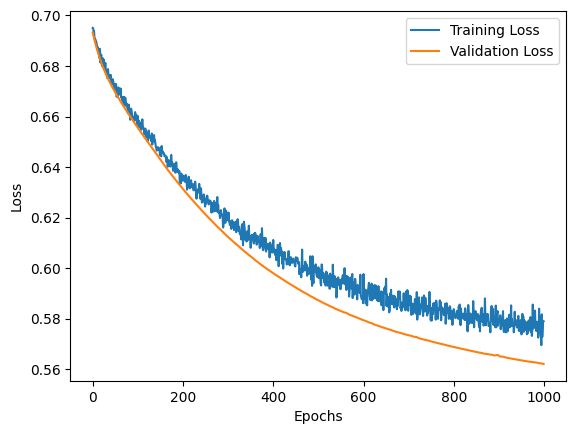

In [15]:
# Define the training function for the GNN
def train_model(epochs, model, optimizer, criterion, data, early_stopper):
    # Make sure device is defined
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Move the data and model to the device
    data = data.to(device)
    model = model.to(device)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # Training
        model.train()
        optimizer.zero_grad()

        # Forward pass on the entire graph
        output = model(data)

        # Calculate loss using the train mask
        train_loss = criterion(output[data.train_mask], data.y[data.train_mask])

        # Backward pass
        train_loss.backward()
        optimizer.step()

        train_losses.append(train_loss.item())

        # Validation
        model.eval()
        with torch.no_grad():
            output = model(data)
            val_loss = criterion(output[data.val_mask], data.y[data.val_mask])
            val_losses.append(val_loss.item())

        print(f'Epoch: {epoch+1}, Training Loss: {train_loss.item():.4f}, Validation Loss: {val_loss.item():.4f}')

        # Early stopping
        early_stopper(val_loss.item(), model)
        if early_stopper.early_stop:
            print("Early stopping triggered.")
            break

    # Load the best model weights
    model.load_state_dict(torch.load('data/gnn_checkpoint.pt'))
    return train_losses, val_losses

# Add the masks to the data object
gnn_views.train_mask = train_mask
gnn_views.val_mask = val_mask
gnn_views.test_mask = test_mask

# Define the optimizer, loss function, and device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
optimizer = optim.Adam(gnn_model.parameters(), lr=0.001, weight_decay=0.0001)

class_counts = torch.bincount(gnn_views.y[gnn_views.train_mask])
class_weights = class_counts.sum() / (len(class_counts) * class_counts.float())
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Initialize early stopping
early_stopper = EarlyStopping(patience=25, min_delta=0.0001, path='data/gnn_checkpoint.pt')

# Train the GNN model
epochs = 1000
train_losses, val_losses = train_model(epochs, gnn_model, optimizer, criterion, gnn_views, early_stopper)

# Plot training and validation losses
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch

# Function to evaluate the model on the validation or test set
def evaluate_model(data, model, mask_type='val'):
    # Make sure device is defined
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Put model and data on the correct device
    model = model.to(device)
    data = data.to(device)

    model.eval()  # Set the model to evaluation mode

    # Determine the appropriate mask
    if mask_type == 'val':
        mask = data.val_mask
    elif mask_type == 'test':
        mask = data.test_mask
    else:
        raise ValueError("mask_type must be 'val' or 'test'")

    # Get predictions with a single forward pass
    with torch.no_grad():
        outputs = model(data)
        if isinstance(outputs, tuple):
            outputs = outputs[0]  # If the model returns a tuple, select only the logits

        _, predicted = torch.max(outputs[mask], 1)  # Get predicted classes for masked nodes

        # Convert to numpy for sklearn metrics
        y_preds = predicted.cpu().numpy()
        y_true = data.y[mask].cpu().numpy()

    # Calculate accuracy and metrics
    accuracy = accuracy_score(y_true, y_preds)
    print("Accuracy:", accuracy)
    print("Classification Report:\n", classification_report(y_true, y_preds, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_preds))

    return accuracy

# Evaluate GNN model on validation set
print("\n---------------GNN MODEL (Validation)---------------\n")
gnn_val_accuracy = evaluate_model(gnn_views, gnn_model, mask_type='val')

# Evaluate GNN model on test set
print("\n---------------GNN MODEL (Test)---------------\n")
gnn_test_accuracy = evaluate_model(gnn_views, gnn_model, mask_type='test')


---------------GNN MODEL (Validation)---------------

Accuracy: 0.7268157753851645
Classification Report:
               precision    recall  f1-score   support

           0     0.8424    0.7432    0.7897     23204
           1     0.5469    0.6903    0.6103     10418

    accuracy                         0.7268     33622
   macro avg     0.6946    0.7168    0.7000     33622
weighted avg     0.7508    0.7268    0.7341     33622

Confusion Matrix:
 [[17245  5959]
 [ 3226  7192]]

---------------GNN MODEL (Test)---------------

Accuracy: 0.723263145372353
Classification Report:
               precision    recall  f1-score   support

           0     0.8393    0.7409    0.7870     23206
           1     0.5424    0.6840    0.6050     10418

    accuracy                         0.7233     33624
   macro avg     0.6908    0.7124    0.6960     33624
weighted avg     0.7473    0.7233    0.7306     33624

Confusion Matrix:
 [[17193  6013]
 [ 3292  7126]]


#### 2.2.2 Task B: Language Prediction
- Target: Multi-class classification of broadcasting language
- Hypothesis: Users follow others who speak their language (language homophily)
- Features: views, mature, life time, dead account, affiliate, temporal features
- Important: The dataset is highly unbalanced, try to implement suitable corrections to
mitigate this problem and/or focus on the top five languages.

In [17]:
features = ['mature', 'life_time', 'dead_account', 'affiliate', 'views']

x = torch.tensor(twitch_nodes[features].values, dtype=torch.float)
y = torch.tensor(twitch_nodes["language_enc"], dtype=torch.long)
gnn_lang = Data(x=x, edge_index=edge_index, y=y)

In [18]:
# Import necessary PyTorch functions and PyTorch Geometric modules
import torch.nn.functional as F  # Contains activation functions, dropout, softmax, etc.
from torch_geometric.nn import GCNConv  # Graph Convolutional Network layer implementation

# Define the Graph Neural Network (GNN) model
# 2 layers of graph convulution, these layers work like mlp layers
class GNN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        """
        Initialize a 2-layer Graph Convolutional Network.

        Args:
            input_dim: Number of input features per node
            hidden_dim: Size of hidden layer (number of features after first convolution)
            output_dim: Number of output classes (final prediction dimension)
        """
        super(GNN, self).__init__()  # Initialize the parent class (torch.nn.Module)

        # First graph convolutional layer
        # Transforms node features from input_dim to hidden_dim dimensions
        self.conv1 = GCNConv(input_dim, hidden_dim)

        # Second graph convolutional layer
        # Transforms node features from hidden_dim to output_dim dimensions
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, data):
        """
        Forward pass through the network.

        Args:
            data: PyTorch Geometric Data object containing:
                - x: Node feature matrix with shape [num_nodes, input_dim]
                - edge_index: Graph connectivity in COO format with shape [2, num_edges]
                  where each column [src, dst] represents an edge

        Returns:
            Log probabilities for each class per node
        """
        # Extract node features and the graph structure
        x, edge_index = data.x, data.edge_index

        # First convolution layer:
        # For each node, aggregate features from its neighbors following the GCN formula
        x = self.conv1(x, edge_index)

        # Apply ReLU activation to introduce non-linearity
        x = F.relu(x)

        # Apply dropout for regularization (only active during training)
        # Randomly zeroes some elements to prevent overfitting
        x = F.dropout(x, training=self.training)

        # Second convolution layer:
        # Further transform node features using neighbor information
        x = self.conv2(x, edge_index)

        return x

# Set up model dimensions based on dataset properties
input_dim = gnn_lang.num_node_features  # Number of features per node in the input dataset
hidden_dim = 16  # Size of hidden representation (hyperparameter that can be tuned)
output_dim = len(torch.unique(gnn_lang.y))  # Number of target classes for classification

# Instantiate the model with the specified dimensions
# .to(device) moves the model to the specified device (GPU if available, CPU otherwise)
gnn_model_lang = GNN(input_dim, hidden_dim, output_dim).to(device)

# Print model architecture summary (layers and parameters)
print(gnn_model_lang)

GNN(
  (conv1): GCNConv(5, 16)
  (conv2): GCNConv(16, 21)
)


In [19]:
from sklearn.model_selection import train_test_split

# Get node indices for each class
class_indices = [torch.where(gnn_lang.y == c)[0] for c in torch.unique(gnn_lang.y)]

train_idx = []
val_idx = []
test_idx = []


# you cannot simply split the graph
# we need to do masking
# Split each class proportionally
for indices in class_indices:
    n_samples = len(indices)
    n_train = int(n_samples * 0.60)  # 60% for training
    n_val = int(n_samples * 0.20)   # 20% for validation

    indices = indices[torch.randperm(len(indices))]  # Shuffle class indices

    train_idx.append(indices[:n_train])
    val_idx.append(indices[n_train:n_train+n_val])
    test_idx.append(indices[n_train+n_val:])

# Concatenate indices from all classes
train_idx = torch.cat(train_idx)
val_idx = torch.cat(val_idx)
test_idx = torch.cat(test_idx)

# Create masks
train_mask = torch.zeros(gnn_lang.num_nodes, dtype=torch.bool)
val_mask = torch.zeros(gnn_lang.num_nodes, dtype=torch.bool)
test_mask = torch.zeros(gnn_lang.num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

#scaling
train_indices = train_mask.cpu().numpy()
X_train = twitch_nodes.loc[train_indices, features].values

scaler = StandardScaler()
scaler.fit(X_train)

X_all_scaled = scaler.transform(twitch_nodes[features].values)

x = torch.tensor(X_all_scaled, dtype=torch.float)
y = torch.tensor(twitch_nodes["language_enc"].values, dtype=torch.long)
gnn_lang = Data(x=x, edge_index=edge_index, y=y)

Epoch: 1, Training Loss: 4.2055, Validation Loss: 4.1982
Validation loss decreased (4.198166 --> 4.198166).  Saving model ...
Epoch: 2, Training Loss: 4.1151, Validation Loss: 4.1699
Validation loss decreased (4.198166 --> 4.169907).  Saving model ...
Epoch: 3, Training Loss: 4.2195, Validation Loss: 4.1420
Validation loss decreased (4.169907 --> 4.141951).  Saving model ...
Epoch: 4, Training Loss: 4.1918, Validation Loss: 4.1144
Validation loss decreased (4.141951 --> 4.114426).  Saving model ...
Epoch: 5, Training Loss: 4.1460, Validation Loss: 4.0874
Validation loss decreased (4.114426 --> 4.087416).  Saving model ...
Epoch: 6, Training Loss: 4.1303, Validation Loss: 4.0609
Validation loss decreased (4.087416 --> 4.060894).  Saving model ...
Epoch: 7, Training Loss: 4.1063, Validation Loss: 4.0348
Validation loss decreased (4.060894 --> 4.034804).  Saving model ...
Epoch: 8, Training Loss: 4.0355, Validation Loss: 4.0092
Validation loss decreased (4.034804 --> 4.009225).  Saving mo

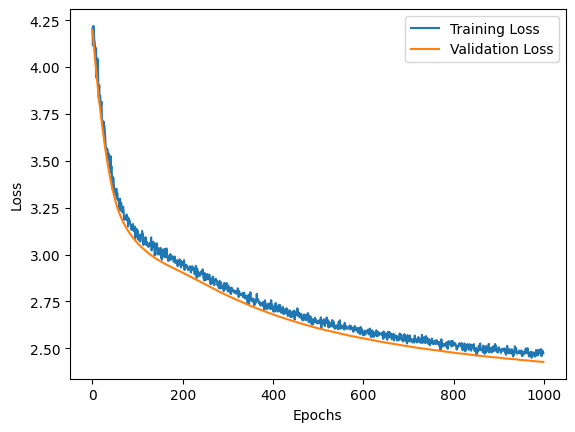

In [20]:
# Define the training function for the GNN
def train_model(epochs, model, optimizer, criterion, data, early_stopper):
    # Make sure device is defined
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Move the data and model to the device
    data = data.to(device)
    model = model.to(device)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # Training
        model.train()
        optimizer.zero_grad()

        # Forward pass on the entire graph
        output = model(data)

        # Calculate loss using the train mask
        train_loss = criterion(output[data.train_mask], data.y[data.train_mask])

        # Backward pass
        train_loss.backward()
        optimizer.step()

        train_losses.append(train_loss.item())

        # Validation
        model.eval()
        with torch.no_grad():
            output = model(data)
            val_loss = criterion(output[data.val_mask], data.y[data.val_mask])
            val_losses.append(val_loss.item())

        print(f'Epoch: {epoch+1}, Training Loss: {train_loss.item():.4f}, Validation Loss: {val_loss.item():.4f}')

        # Early stopping
        early_stopper(val_loss.item(), model)
        if early_stopper.early_stop:
            print("Early stopping triggered.")
            break

    # Load the best model weights
    model.load_state_dict(torch.load('data/gnn_checkpoint_lang.pt'))
    return train_losses, val_losses

# Add the masks to the data object
gnn_lang.train_mask = train_mask
gnn_lang.val_mask = val_mask
gnn_lang.test_mask = test_mask

# Define the optimizer, loss function, and device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
optimizer = optim.Adam(gnn_model_lang.parameters(), lr=0.001, weight_decay=0.0001)

class_counts = torch.bincount(gnn_lang.y[gnn_lang.train_mask])
class_weights = 1.0 / (class_counts.float() + 1e-8)
class_weights = class_weights * (len(class_counts) / class_weights.sum())
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device)) 

# Initialize early stopping
early_stopper = EarlyStopping(patience=25, min_delta=0.0001, path='data/gnn_checkpoint_lang.pt')

# Train the GNN model
epochs = 1000
train_losses, val_losses = train_model(epochs, gnn_model_lang, optimizer, criterion, gnn_lang, early_stopper)

# Plot training and validation losses
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch

# Function to evaluate the model on the validation or test set
def evaluate_model(data, model, mask_type='val'):
    # Make sure device is defined
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Put model and data on the correct device
    model = model.to(device)
    data = data.to(device)

    model.eval()  # Set the model to evaluation mode

    # Determine the appropriate mask
    if mask_type == 'val':
        mask = data.val_mask
    elif mask_type == 'test':
        mask = data.test_mask
    else:
        raise ValueError("mask_type must be 'val' or 'test'")

    # Get predictions with a single forward pass
    with torch.no_grad():
        outputs = model(data)
        if isinstance(outputs, tuple):
            outputs = outputs[0]  # If the model returns a tuple, select only the logits

        _, predicted = torch.max(outputs[mask], 1)  # Get predicted classes for masked nodes

        # Convert to numpy for sklearn metrics
        y_preds = predicted.cpu().numpy()
        y_true = data.y[mask].cpu().numpy()

    # Calculate accuracy and metrics
    accuracy = accuracy_score(y_true, y_preds)
    print("Accuracy:", accuracy)
    print("Classification Report:\n", classification_report(y_true, y_preds, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_preds))

    return accuracy

# Evaluate GNN model on validation set
print("\n---------------GNN MODEL (Validation)---------------\n")
gnn_val_accuracy = evaluate_model(gnn_lang, gnn_model_lang, mask_type='val')

# Evaluate GNN model on test set
print("\n---------------GNN MODEL (Test)---------------\n")
gnn_test_accuracy = evaluate_model(gnn_lang, gnn_model_lang, mask_type='test')


---------------GNN MODEL (Validation)---------------

Accuracy: 0.17805081216159932
Classification Report:
               precision    recall  f1-score   support

           0     0.1226    0.5565    0.2009       115
           1     0.0217    0.2800    0.0403       100
           2     0.1877    0.6488    0.2911      1885
           3     0.9338    0.1281    0.2253     24882
           4     0.1725    0.1133    0.1367      1139
           5     0.0088    0.2000    0.0169       130
           6     0.2595    0.1906    0.2198      1359
           7     0.0133    0.0706    0.0224        85
           8     0.0867    0.1829    0.1176       246
           9     0.1178    0.2377    0.1575       265
          10     0.1281    0.6955    0.2164       243
          11     0.0155    0.0143    0.0149       140
          12     0.0087    0.3030    0.0169        66
          13     0.0504    0.3649    0.0886       285
          14     0.1040    0.4149    0.1663       188
          15     0.0332   

#### Baseline MLP


In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split


x = torch.tensor(twitch_nodes[features].values, dtype=torch.float)
y = torch.tensor((twitch_nodes["views"] > 10000).astype(int).values, dtype=torch.long)

gnn_views = Data(x=x, edge_index=edge_index, y=y)

train_size = int(0.6 * len(gnn_views.x))
val_size = int(0.2 * len(gnn_views.x))
test_size = len(gnn_views.x) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    TensorDataset(gnn_views.x, gnn_views.y),
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # For reproducibility
)

In [23]:
from torchsummary import summary

# Define the MLP model for multiclass classification
class MLP_Classifier(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP_Classifier, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, output_dim)
#nn.LogSoftmax(dim=1) # linear activation here, because softmax is done in the criterion

        )

    def forward(self, x):
        return self.layers(x)

input_dim = gnn_views.x.shape[1]
output_dim = 2
model = MLP_Classifier(input_dim, output_dim).to(device)

# Summary of the model structure
summary(model, input_size=(input_dim,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 32]             192
              ReLU-2                   [-1, 32]               0
           Dropout-3                   [-1, 32]               0
            Linear-4                   [-1, 16]             528
              ReLU-5                   [-1, 16]               0
           Dropout-6                   [-1, 16]               0
            Linear-7                    [-1, 2]              34
Total params: 754
Trainable params: 754
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [24]:
#EARLY STOPPING

class EarlyStopping:
    def __init__(self, patience=25, min_delta=0.0001, path='checkpoint.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.path = path  # Path to save the best model

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            if val_loss < self.best_loss:
                self.save_checkpoint(val_loss, model)
                self.best_loss = val_loss
                self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decrease.'''
        torch.save(model.state_dict(), self.path)
        print(f'Validation loss decreased ({self.best_loss:.6f} --> {val_loss:.6f}).  Saving model ...')

# Function for training the model
def train_model(epochs, model, optimizer, criterion, train_loader, val_loader, early_stopper):
    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_losses.append(train_loss / len(train_loader))

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)
                val_loss += loss.item()
        val_losses.append(val_loss / len(val_loader))
        print(f'Epoch: {epoch+1}, Training Loss: {train_loss / len(train_loader):.4f}, Validation Loss: {val_loss / len(val_loader):.4f}')

        # Early stopping call and pass the model for checkpointing
        early_stopper(val_loss, model)
        if early_stopper.early_stop:
            print("Early stopping triggered.")
            break

    # Load the best model weights
    model.load_state_dict(torch.load('mlp_checkpoint.pt'))
    return train_losses, val_losses

Epoch: 1, Training Loss: 138.3212, Validation Loss: 0.6079
Validation loss decreased (159.881192 --> 159.881192).  Saving model ...
Epoch: 2, Training Loss: 7.6641, Validation Loss: 0.4931
Validation loss decreased (159.881192 --> 129.685530).  Saving model ...
Epoch: 3, Training Loss: 2.0783, Validation Loss: 0.6584
Epoch: 4, Training Loss: 1.1327, Validation Loss: 0.4023
Validation loss decreased (129.685530 --> 105.806425).  Saving model ...
Epoch: 5, Training Loss: 0.6620, Validation Loss: 3.5447
Epoch: 6, Training Loss: 1.0461, Validation Loss: 0.6251
Epoch: 7, Training Loss: 0.8089, Validation Loss: 0.6210
Epoch: 8, Training Loss: 0.6801, Validation Loss: 0.6216
Epoch: 9, Training Loss: 0.6253, Validation Loss: 0.6210
Early stopping triggered.


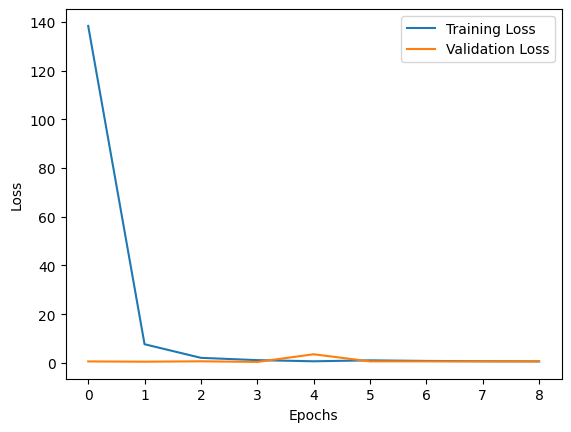

In [25]:
# Create DataLoaders for the datasets
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)

# Initialize early stopping
early_stopper = EarlyStopping(patience=5, min_delta=0.0001, path='mlp_checkpoint.pt')

# Train the model and plot losses
epochs = 50
train_losses, val_losses = train_model(epochs, model, optimizer, criterion, train_loader, val_loader, early_stopper)

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch

# Function to evaluate the model on the validation set
def evaluate_model(data_loader, model):
    model.eval()  # Set the model to evaluation mode
    y_true = []
    y_preds = []

    # Collect all labels and model outputs
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]  # If the model returns a tuple, select only the logits
            _, predicted = torch.max(outputs, 1)  # Get the index of the max log-probability
            y_preds.extend(predicted.view(-1).cpu().numpy())  # Store predictions
            y_true.extend(labels.cpu().numpy())

    # Calculate accuracy
    accuracy = accuracy_score(y_true, y_preds)
    print("Accuracy:", accuracy)
    print("Classification Report:\n", classification_report(y_true, y_preds, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_preds))

    return accuracy

# Evaluate mlp model
print("\n---------------MLP MODEL VALIDATION---------------\n")
mlp_accuracy = evaluate_model(val_loader, model)


---------------MLP MODEL VALIDATION---------------

Accuracy: 0.8042650645410743
Classification Report:
               precision    recall  f1-score   support

           0     0.7794    1.0000    0.8761     23258
           1     1.0000    0.3650    0.5348     10364

    accuracy                         0.8043     33622
   macro avg     0.8897    0.6825    0.7054     33622
weighted avg     0.8474    0.8043    0.7709     33622

Confusion Matrix:
 [[23258     0]
 [ 6581  3783]]


### 3 Bonus Tasks
#### 3.1 Bonus Task 1: GraphSAGE Implementation (1 bonus point)
- Implement GraphSAGE for one of the two tasks
- Compare its performance with the convolutional GNN

In [27]:
features = ['mature', 'life_time', 'dead_account', 'affiliate', 'views']

x = torch.tensor(twitch_nodes[features].values, dtype=torch.float)
y = torch.tensor(twitch_nodes["language_enc"], dtype=torch.long)
gnn_lang = Data(x=x, edge_index=edge_index, y=y)

In [28]:
from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GraphSAGE, self).__init__()
        self.sage1 = SAGEConv(input_dim, hidden_dim)
        self.sage2 = SAGEConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.sage1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.sage2(x, edge_index)
        return x



input_dim = gnn_lang.num_node_features   
hidden_dim = 64                  
output_dim = len(torch.unique(gnn_lang.y)) 

sage_model = GraphSAGE(input_dim, hidden_dim, output_dim).to(device)
print(sage_model)

GraphSAGE(
  (sage1): SAGEConv(5, 64, aggr=mean)
  (sage2): SAGEConv(64, 21, aggr=mean)
)


In [29]:
from sklearn.model_selection import train_test_split

# Get node indices for each class
class_indices = [torch.where(gnn_lang.y == c)[0] for c in torch.unique(gnn_lang.y)]

train_idx = []
val_idx = []
test_idx = []


# you cannot simply split the graph
# we need to do masking
# Split each class proportionally
for indices in class_indices:
    n_samples = len(indices)
    n_train = int(n_samples * 0.60)  # 60% for training
    n_val = int(n_samples * 0.20)   # 20% for validation

    indices = indices[torch.randperm(len(indices))]  # Shuffle class indices

    train_idx.append(indices[:n_train])
    val_idx.append(indices[n_train:n_train+n_val])
    test_idx.append(indices[n_train+n_val:])

# Concatenate indices from all classes
train_idx = torch.cat(train_idx)
val_idx = torch.cat(val_idx)
test_idx = torch.cat(test_idx)

# Create masks
train_mask = torch.zeros(gnn_lang.num_nodes, dtype=torch.bool)
val_mask = torch.zeros(gnn_lang.num_nodes, dtype=torch.bool)
test_mask = torch.zeros(gnn_lang.num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

#scaling
train_indices = train_mask.cpu().numpy()
X_train = twitch_nodes.loc[train_indices, features].values

scaler = StandardScaler()
scaler.fit(X_train)

X_all_scaled = scaler.transform(twitch_nodes[features].values)

x = torch.tensor(X_all_scaled, dtype=torch.float)
y = torch.tensor(twitch_nodes["language_enc"].values, dtype=torch.long)
gnn_lang = Data(x=x, edge_index=edge_index, y=y)


Epoch: 1, Training Loss: 3.8433, Validation Loss: 3.5529
Validation loss decreased (3.552866 --> 3.552866).  Saving model ...
Epoch: 2, Training Loss: 3.7597, Validation Loss: 3.4596
Validation loss decreased (3.552866 --> 3.459560).  Saving model ...
Epoch: 3, Training Loss: 3.7200, Validation Loss: 3.3775
Validation loss decreased (3.459560 --> 3.377527).  Saving model ...
Epoch: 4, Training Loss: 3.6515, Validation Loss: 3.3093
Validation loss decreased (3.377527 --> 3.309327).  Saving model ...
Epoch: 5, Training Loss: 3.6144, Validation Loss: 3.2541
Validation loss decreased (3.309327 --> 3.254098).  Saving model ...
Epoch: 6, Training Loss: 3.5305, Validation Loss: 3.2071
Validation loss decreased (3.254098 --> 3.207134).  Saving model ...
Epoch: 7, Training Loss: 3.4725, Validation Loss: 3.1674
Validation loss decreased (3.207134 --> 3.167367).  Saving model ...
Epoch: 8, Training Loss: 3.4011, Validation Loss: 3.1353
Validation loss decreased (3.167367 --> 3.135284).  Saving mo

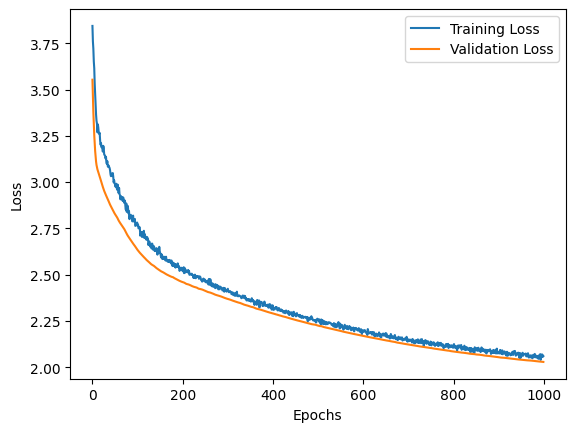

In [30]:
# Define the training function for the GNN
def train_model(epochs, model, optimizer, criterion, data, early_stopper):
    # Make sure device is defined
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Move the data and model to the device
    data = data.to(device)
    model = model.to(device)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # Training
        model.train()
        optimizer.zero_grad()

        # Forward pass on the entire graph
        output = model(data)

        # Calculate loss using the train mask
        train_loss = criterion(output[data.train_mask], data.y[data.train_mask])

        # Backward pass
        train_loss.backward()
        optimizer.step()

        train_losses.append(train_loss.item())

        # Validation
        model.eval()
        with torch.no_grad():
            output = model(data)
            val_loss = criterion(output[data.val_mask], data.y[data.val_mask])
            val_losses.append(val_loss.item())

        print(f'Epoch: {epoch+1}, Training Loss: {train_loss.item():.4f}, Validation Loss: {val_loss.item():.4f}')

        # Early stopping
        early_stopper(val_loss.item(), model)
        if early_stopper.early_stop:
            print("Early stopping triggered.")
            break

    # Load the best model weights
    model.load_state_dict(torch.load('data/gnn_sage_checkpoint_lang.pt'))
    return train_losses, val_losses

# Add the masks to the data object
gnn_lang.train_mask = train_mask
gnn_lang.val_mask = val_mask
gnn_lang.test_mask = test_mask

# Define the optimizer, loss function, and device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
optimizer = optim.Adam(sage_model.parameters(), lr=0.001, weight_decay=0.0001)

class_counts = torch.bincount(gnn_lang.y[gnn_lang.train_mask])
class_weights = class_counts.sum() / (len(class_counts) * class_counts.float())
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))


# Initialize early stopping
early_stopper = EarlyStopping(patience=25, min_delta=0.0001, path='data/gnn_sage_checkpoint_lang.pt')

# Train the GNN model
epochs = 1000
train_losses, val_losses = train_model(epochs, sage_model, optimizer, criterion, gnn_lang, early_stopper)

# Plot training and validation losses
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [31]:
# Function to evaluate the model on the validation or test set
def evaluate_model(data, model, mask_type='val'):
    # Make sure device is defined
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Put model and data on the correct device
    model = model.to(device)
    data = data.to(device)

    model.eval()  # Set the model to evaluation mode

    # Determine the appropriate mask
    if mask_type == 'val':
        mask = data.val_mask
    elif mask_type == 'test':
        mask = data.test_mask
    else:
        raise ValueError("mask_type must be 'val' or 'test'")

    # Get predictions with a single forward pass
    with torch.no_grad():
        outputs = model(data)
        if isinstance(outputs, tuple):
            outputs = outputs[0]  # If the model returns a tuple, select only the logits

        _, predicted = torch.max(outputs[mask], 1)  # Get predicted classes for masked nodes

        # Convert to numpy for sklearn metrics
        y_preds = predicted.cpu().numpy()
        y_true = data.y[mask].cpu().numpy()

    # Calculate accuracy and metrics
    accuracy = accuracy_score(y_true, y_preds)
    print("Accuracy:", accuracy)
    print("Classification Report:\n", classification_report(y_true, y_preds, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_preds))

    return accuracy

# Evaluate GNN model on validation set
print("\n---------------GNN MODEL (Validation)---------------\n")
gnn_val_accuracy = evaluate_model(gnn_lang, sage_model, mask_type='val')




---------------GNN MODEL (Validation)---------------

Accuracy: 0.27095852918426844
Classification Report:
               precision    recall  f1-score   support

           0     0.0968    0.6348    0.1680       115
           1     0.0363    0.5400    0.0680       100
           2     0.4364    0.6790    0.5313      1885
           3     0.9598    0.2149    0.3511     24882
           4     0.3706    0.1282    0.1905      1139
           5     0.0107    0.3769    0.0208       130
           6     0.3805    0.3481    0.3636      1359
           7     0.0520    0.3765    0.0914        85
           8     0.1255    0.3862    0.1894       246
           9     0.1354    0.4528    0.2085       265
          10     0.5086    0.7284    0.5990       243
          11     0.0083    0.0786    0.0151       140
          12     0.0057    0.2727    0.0111        66
          13     0.1402    0.4947    0.2184       285
          14     0.1417    0.3777    0.2061       188
          15     0.2031   

In [32]:
# comparison
print("\n---------------SAGE MODEL (TEST)---------------\n")
print(evaluate_model(gnn_lang, sage_model, mask_type='test'))

print("\n---------------GNN MODEL (TEST)---------------\n")
print(evaluate_model(gnn_lang, gnn_model_lang, mask_type='test'))


---------------SAGE MODEL (TEST)---------------

Accuracy: 0.27170035671819265
Classification Report:
               precision    recall  f1-score   support

           0     0.1056    0.6466    0.1816       116
           1     0.0300    0.4412    0.0563       102
           2     0.4311    0.6852    0.5293      1887
           3     0.9573    0.2119    0.3470     24883
           4     0.4368    0.1394    0.2113      1141
           5     0.0117    0.4198    0.0227       131
           6     0.3772    0.3262    0.3499      1361
           7     0.0544    0.4070    0.0960        86
           8     0.1197    0.3780    0.1818       246
           9     0.1594    0.5113    0.2431       266
          10     0.4513    0.7243    0.5561       243
          11     0.0139    0.1277    0.0250       141
          12     0.0053    0.2424    0.0103        66
          13     0.1466    0.5401    0.2307       287
          14     0.1476    0.4000    0.2156       190
          15     0.1824    0.24

#### 3.2 Bonus Task 2: Regression Task (2 bonus points)
- Train a GNN for regression on the number of views (continuous target)
- Compare with MLP regression baseline
- Use appropriate regression metrics (RMSE, MAE, MAPE)

Epoch: 1, Training Loss: 65016745164800.0000, Validation Loss: 39079806763008.0000
Validation loss decreased (39079806763008.000000 --> 39079806763008.000000).  Saving model ...
Epoch: 2, Training Loss: 49488764862464.0000, Validation Loss: 33104880205824.0000
Validation loss decreased (39079806763008.000000 --> 33104880205824.000000).  Saving model ...
Epoch: 3, Training Loss: 42444485820416.0000, Validation Loss: 28092831629312.0000
Validation loss decreased (33104880205824.000000 --> 28092831629312.000000).  Saving model ...
Epoch: 4, Training Loss: 47239875526656.0000, Validation Loss: 23860671938560.0000
Validation loss decreased (28092831629312.000000 --> 23860671938560.000000).  Saving model ...
Epoch: 5, Training Loss: 31892866859008.0000, Validation Loss: 20572004155392.0000
Validation loss decreased (23860671938560.000000 --> 20572004155392.000000).  Saving model ...
Epoch: 6, Training Loss: 30922604806144.0000, Validation Loss: 18081321582592.0000
Validation loss decreased (

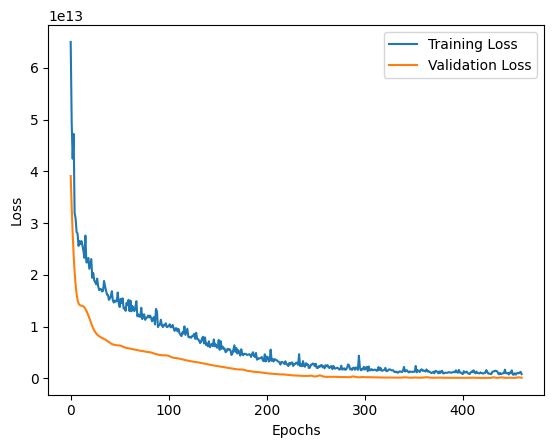

In [33]:
#y_reg = np.log1p(twitch_nodes['views'].values)
y_reg = twitch_nodes['views'].values
y = torch.tensor(y_reg, dtype=torch.float)

class GraphSAGE_Regressor(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.sage1 = SAGEConv(input_dim, hidden_dim)
        self.sage2 = SAGEConv(hidden_dim, 1)  # Nur 1 Output für Regression

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.sage1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, 0.3, training=self.training)
        x = self.sage2(x, edge_index)
        return x.view(-1)


input_dim = gnn_views.num_node_features
hidden_dim = 64
gnn_reg = GraphSAGE_Regressor(input_dim, hidden_dim).to(device)

# Add the masks to the data object
reg_data = Data(x=gnn_views.x, edge_index=gnn_views.edge_index, y=y)
reg_data.train_mask = train_mask
reg_data.val_mask = val_mask
reg_data.test_mask = test_mask
def train_model(epochs, model, optimizer, criterion, data, early_stopper):
    # Make sure device is defined
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Move the data and model to the device
    data = data.to(device)
    model = model.to(device)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # Training
        model.train()
        optimizer.zero_grad()

        # Forward pass on the entire graph
        output = model(data)

        # Calculate loss using the train mask
        train_loss = criterion(output[data.train_mask], data.y[data.train_mask])

        # Backward pass
        train_loss.backward()
        optimizer.step()

        train_losses.append(train_loss.item())

        # Validation
        model.eval()
        with torch.no_grad():
            output = model(data)
            val_loss = criterion(output[data.val_mask], data.y[data.val_mask])
            val_losses.append(val_loss.item())

        print(f'Epoch: {epoch+1}, Training Loss: {train_loss.item():.4f}, Validation Loss: {val_loss.item():.4f}')

        # Early stopping
        early_stopper(val_loss.item(), model)
        if early_stopper.early_stop:
            print("Early stopping triggered.")
            break

    # Load the best model weights
    model.load_state_dict(torch.load('data/gnn_sage_checkpoint_reg.pt'))
    return train_losses, val_losses


# Define the optimizer, loss function, and device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
optimizer = optim.Adam(gnn_reg.parameters(), lr=0.001, weight_decay=0.0001)

# class_counts = torch.bincount(gnn_views.y[gnn_views.train_mask])
# class_weights = class_counts.sum() / (len(class_counts) * class_counts.float())
# criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
criterion = nn.MSELoss()

# Initialize early stopping
early_stopper = EarlyStopping(patience=25, min_delta=0.0001, path='data/gnn_sage_checkpoint_reg.pt')

# Train the GNN model
epochs = 1000
train_losses, val_losses = train_model(epochs, gnn_reg, optimizer, criterion, reg_data, early_stopper)

# Plot training and validation losses
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

/home/jovyan/.dlss/lib/python3.11/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/jovyan/.dlss/lib/python3.11/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([4, 1])) that is different to the input size (torch.Size([4])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/jovyan/.dlss/lib/python3.11/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([24, 1])) that is different to the input size (torch.Size([24])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  re

Epoch: 1, Training Loss: 2545093685.9472, Validation Loss: 42937411252.8584
Validation loss decreased (42937411252.858368 --> 42937411252.858368).  Saving model ...
Epoch: 2, Training Loss: 584602294.6229, Validation Loss: 35529.5381
Validation loss decreased (42937411252.858368 --> 35529.538083).  Saving model ...
Epoch: 3, Training Loss: 7355909952.7268, Validation Loss: 1004498.0620
Epoch: 4, Training Loss: 1356923.4967, Validation Loss: 104.0754
Validation loss decreased (35529.538083 --> 104.075446).  Saving model ...
Epoch: 5, Training Loss: 98.8628, Validation Loss: 83.7864
Validation loss decreased (104.075446 --> 83.786413).  Saving model ...
Epoch: 6, Training Loss: 121.5176, Validation Loss: 12158.3958
Epoch: 7, Training Loss: 79454764.4457, Validation Loss: 37651.6859
Epoch: 8, Training Loss: 780396367.2192, Validation Loss: 109465.4115
Epoch: 9, Training Loss: 273173942.5205, Validation Loss: 14760.1577
Epoch: 10, Training Loss: 361287.4518, Validation Loss: 375033.1860
Ep

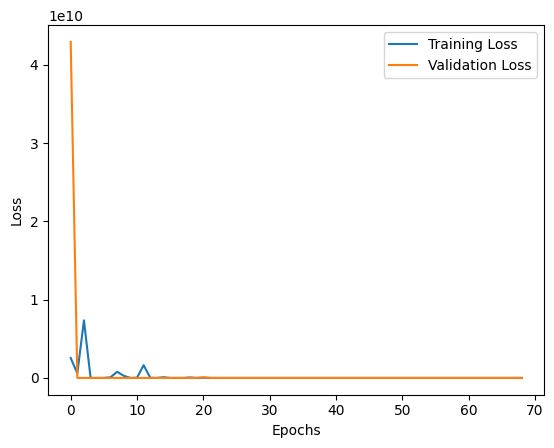

In [34]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.layers(x).view(-1)
    
input_dim = reg_data.num_node_features

model_reg = MLPRegressor(input_dim).to(device)

# Daten splitten (wie beim MLP-Classifier)
from torch.utils.data import TensorDataset, DataLoader, random_split

y_reg = np.log1p(twitch_nodes['views'].values)
y = torch.tensor(y_reg, dtype=torch.float)

dataset = TensorDataset(torch.tensor(gnn_views.x.cpu().numpy(), dtype=torch.float), y)
train_size = int(0.6 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

def train_model(epochs, model, optimizer, criterion, train_loader, val_loader, early_stopper):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        batch_train_losses = []

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target.view(-1, 1))
            loss.backward()
            optimizer.step()
            batch_train_losses.append(loss.item())

        mean_train_loss = np.mean(batch_train_losses)
        train_losses.append(mean_train_loss)

        model.eval()
        batch_val_losses = []
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                val_loss = criterion(output, target.view(-1, 1))
                batch_val_losses.append(val_loss.item())

        mean_val_loss = np.mean(batch_val_losses)
        val_losses.append(mean_val_loss)

        # Now, print and early stopping based on mean_val_loss
        print(f'Epoch: {epoch+1}, Training Loss: {mean_train_loss:.4f}, Validation Loss: {mean_val_loss:.4f}')

        early_stopper(mean_val_loss, model)
        if early_stopper.early_stop:
            print("Early stopping triggered.")
            break

    # Load the best model weights
    model.load_state_dict(torch.load(early_stopper.path))
    return train_losses, val_losses

criterion = nn.MSELoss()

# Instantiate optimizer and early stopper
optimizer = optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=0.0001)
early_stopper = EarlyStopping(patience=25, min_delta=0.0001, path='data/mlp_checkpoint_reg.pt')
epochs = 500

# Run training and plot losses
train_losses, val_losses = train_model(epochs, model_reg, optimizer, criterion, train_loader, test_loader, early_stopper)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



In [35]:
# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

def evaluate_regression_mlp(data_loader, model):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for data, target in data_loader:
            data = data.to(device)
            output = model(data)
            y_pred.extend(output.view(-1).cpu().numpy())
            y_true.extend(target.cpu().numpy())

    mape = mean_absolute_percentage_error(np.exp(y_true), np.exp(y_pred))
    mae = mean_absolute_error(np.exp(y_true), np.exp(y_pred))
    mse = mean_squared_error(np.exp(y_true), np.exp(y_pred))
    rmse = np.sqrt(mse)

    print(f"MAPE: {mape:.4f}, MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}")
    return mse, mae, mape, rmse


def evaluate_regression_gnn(data, model, mask_type='test'):
    model.eval()
    device = next(model.parameters()).device
    data = data.to(device)
    
    if mask_type == 'test':
        mask = data.test_mask
    elif mask_type == 'val':
        mask = data.val_mask
    else:
        mask = data.train_mask
    
    with torch.no_grad():
        output = model(data)
        y_pred = output[mask].cpu().numpy()
        y_true = data.y[mask].cpu().numpy()
    
    # Safe exponential transformation
    y_true_exp = np.exp(np.clip(y_true, -700, 700))
    y_pred_exp = np.exp(np.clip(y_pred, -700, 700))
    
    # Ensure finite values for MAPE calculation
    finite_mask = np.isfinite(y_true_exp) & np.isfinite(y_pred_exp) & (y_true_exp != 0)
    
    if np.sum(finite_mask) > 0:
        mape = mean_absolute_percentage_error(y_true_exp[finite_mask], y_pred_exp[finite_mask])
        mae = mean_absolute_error(y_true_exp[finite_mask], y_pred_exp[finite_mask])
        mse = mean_squared_error(y_true_exp[finite_mask], y_pred_exp[finite_mask])
        rmse = np.sqrt(mse)
    else:
        mape = mae = mse = rmse = np.nan
    
    #print(f"MAPE: {mape:.4f}, MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}")
    return mse, mae, mape, rmse


In [36]:
# MLP-Evaluation
print("=== MLP Regression Results ===")
mse_mlp, mae_mlp, mape_mlp, rmse_mlp = evaluate_regression_mlp(test_loader, model_reg)

# GNN-Evaluation  
print("=== GNN Regression Results ===")
mse_gnn, mae_gnn, mape_gnn, rmse_gnn = evaluate_regression_gnn(reg_data, gnn_reg, mask_type='test')

=== MLP Regression Results ===
MAPE: 5.9710, MAE: 165378.3906, MSE: 8482729754624.0000, RMSE: 2912512.6188
=== GNN Regression Results ===


/tmp/ipykernel_1332/4033211985.py:43: RuntimeWarning: overflow encountered in exp
  y_true_exp = np.exp(np.clip(y_true, -700, 700))
/tmp/ipykernel_1332/4033211985.py:44: RuntimeWarning: overflow encountered in exp
  y_pred_exp = np.exp(np.clip(y_pred, -700, 700))
/home/jovyan/.dlss/lib/python3.11/site-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)


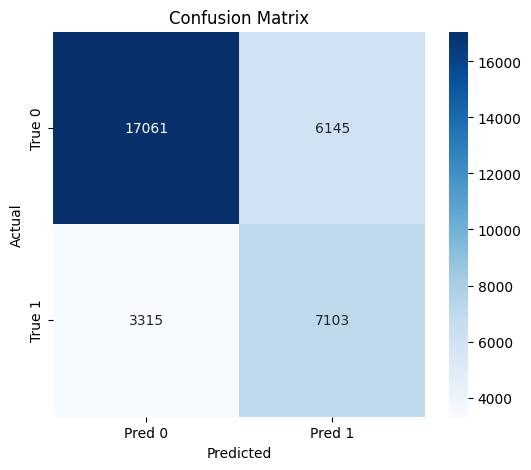

In [37]:
# confusion matrix

cm = np.array([[17061, 6145],
               [3315, 7103]])

# Create a DataFrame for better visualization
cm_df = pd.DataFrame(cm, 
                     index=['True 0', 'True 1'], 
                     columns=['Pred 0', 'Pred 1'])
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()